# 18 - ceff2(f, eta) empirical formula: extraction, fit, P(k) validation

**Deliverable:** an explicit fitted formula for the daughter's effective sound speed,

$$c_{\rm eff}^2(f, \eta) = \tfrac{1}{3}\left(1 - e^{-3 A(f)\,\eta}\right), \qquad A(f) = A_0\,(1 + B f),$$

at the **fixed production configuration** kappa = 6, a_t = 0.13, m = 1e16 GeV. Those knobs are stated once in the setup cell as the CALIBRATION DOMAIN -- everything else in this notebook depends only on the two scanned model inputs `f` (daughter fraction) and `eta` (injection kick).

**Why:** the eta-only law `A_eta = 0.55` (nb17) was fit at f = 0.1 only; nb15 saw the plateau f-independent to ~0.5% at three eta values but never *fit* the f-dependence or P(k)-validated it across the grid -- in particular not at the physics target f = 0.3. If the fitted B comes out consistent with 0, f-independence is demonstrated, not assumed.

**Stages** (each pickle-cached under `accDM_scans/nb18_cache/`):

- **A. Plateau extraction** over f x eta = {0.03, 0.1, 0.2, 0.3} x {0.01, 0.05, 0.1, 0.3, 0.5}: exact hierarchy, pole-masked median of `cs2_ncdm[1] = delta_p/delta_rho` over the flat window x = k/k_fs in [0.05, 30].
- **B. Fit:** de-saturate (y = -ln(1-3c)/3, so y = A(f)*eta is linear), fit per-f slopes, then A(f) = A0(1+B f); eta-only null model vs f-corrected model with residual tables; deliverable `ceff2_formula(f, eta)`.
- **C. P(k) validation** at 5 (f, eta) corners including f = 0.3, scored over **k <= 1 Mpc^-1 ONLY** (nb7 lesson), ~1% target; C-vs-python mode assertion runs first (nb16 typo lesson).

Standing rule: if P(k) misses 1% with the correct ceff2, the shear closure `cvis2` is the **named suspect** -- do not tune ceff2 further. Requires the rebuilt `classy` with `ncdm_ceff2_mode = 3`.

In [1]:
import sys, os, time, pickle; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class
from fluid_closure_helpers import (
    mask_small_denom, eta_plateau_cfs, desaturate_cfs,
    fit_eta_slope, fit_A_of_f, A_eff_of_f, ceff2_f_eta)

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# --- base cosmology (same as nb15/nb16/nb17) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}

# === CALIBRATION DOMAIN: the formula fitted below is valid at THESE knobs only ===
KAPPA = 6.0        # production-window sharpness  (fixed)
A_T   = 0.13       # production epoch             (fixed)
MASS  = 1e16       # parent/daughter mass [GeV]   (fixed)
A_REC = 1.0 / (1.0 + 1090.0)
# f (daughter fraction) and eta (injection kick) are the ONLY scanned model
# inputs -- every builder below takes them explicitly, nothing else varies.

# --- Stage A: extraction grid ---
F_SCAN    = [0.03, 0.1, 0.2, 0.3]
ETA_SCAN  = [0.01, 0.05, 0.1, 0.3, 0.5]
K_GRID    = np.logspace(-2, 0.0, 18)      # k_output_values for extraction
Q_EXTRACT = 501                           # nb15-v3 grid the A_eta=0.55 fit came from
DROP_FRAC = 0.2                           # pole mask: drop smallest 20% of |delta|
X_WINDOW  = (0.05, 30.0)                  # flat plateau band in x=k/k_fs (2026-07-13)

# --- Stage C: P(k) validation ---
K_PK    = np.logspace(-3, 0.0, 40)        # score k <= 1 ONLY (nb7 lesson)
TRIGGER = 10.0                             # safe switch-on (nb17)
CORNERS = [(0.1, 0.05), (0.1, 0.5), (0.3, 0.05), (0.3, 0.5), (0.2, 0.1)]

def q_exact_of_f(f_acc):
    """Converged exact-reference q-grid (memory: accdm-fluid-f-boundary)."""
    return 1001 if f_acc <= 0.1 else 5001

CACHE_DIR = os.path.join('accDM_scans', 'nb18_cache'); os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_TAG = 'v1'                          # bump after any extractor/params change

def accdm_params(f_acc, eta, q_size):
    """Exact-hierarchy accDM params. f_acc/eta are the scan inputs; the
    production knobs come from the CALIBRATION DOMAIN constants above."""
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))**(-1)
    p = dict(base_params); p.update(PREC)
    p.update({'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
              'f_acc': f_acc, 'eta_acc': eta,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
              'ncdm_N_momentum_bins': '15, {}'.format(q_size), 'N_ur': 0.00441,
              'background_Nloga': 5001, 'gauge': 'synchronous',
              'get_perturbations_in_current_gauge': 'yes',
              'ncdm_fluid_trigger_tau_over_tau_k': 25,
              'ncdm_fluid_approximation': 3})           # 3 = none (exact hierarchy)
    return p

def fluid_params(f_acc, eta, A_eff, trigger=TRIGGER):
    """Mode-3 fluid params. The f-dependence of the formula enters ONLY through
    A_eff = A(f), passed to CLASS as ncdm_ceff2_eta_A."""
    p = accdm_params(f_acc, eta, q_exact_of_f(f_acc))
    p['ncdm_fluid_approximation'] = 2
    p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger
    p['switch_off_shear_acc'] = 'no'      # never judge the fluid with frozen shear
    p['ncdm_ceff2_mode'] = 3
    p['ncdm_ceff2_eta_A'] = float(A_eff)
    return p

print('setup OK: {} x {} = {} extraction configs; P(k) corners: {}'.format(
    len(F_SCAN), len(ETA_SCAN), len(F_SCAN)*len(ETA_SCAN), CORNERS))

setup OK: 4 x 5 = 20 extraction configs; P(k) corners: [(0.1, 0.05), (0.1, 0.5), (0.3, 0.05), (0.3, 0.5), (0.2, 0.1)]


## Stage A - plateau extraction over the (f, eta) grid

One exact-hierarchy run per grid point with `k_output_values = K_GRID` (18 k in [0.01, 1]), q_size = 501 -- the same nb15-v3 setup the A_eta = 0.55 calibration was measured on, so Stage B refits the same observable rather than a resolution-shifted one. The plateau per config is the **median pole-masked** `delta_p/delta_rho` over the flat window x = k/k_fs in [0.05, 30]; x > 30 is excluded deliberately (delta_rho zero-crossing phase-mixing + q-grid artifacts, memory `ceff2-fit-structure`).

The headline number of this stage is the **f-spread column**: (max-min)/median of the plateau across f at fixed eta. nb15 saw ~0.5%; if it stays at that level the f-correction in Stage B has nothing to fit.

In [2]:
def _find_key(d, want):
    if want in d:
        return want
    for kk in d:
        if kk.replace(' ', '').startswith(want.replace(' ', '')):
            return kk
    raise KeyError('{!r} not found; available: {}'.format(want, list(d.keys())))

def extract_daughter_series(params, k_list):
    """Run exact CLASS; return {k: dict of daughter tau-series arrays} (nb15 extractor)."""
    ks = np.sort(np.asarray(k_list, float))
    p = dict(params); p['k_output_values'] = ', '.join('{:.8e}'.format(k) for k in ks)
    M = Class(); M.set(p); M.compute()
    perts = M.get_perturbations()['scalar']
    bg = M.get_background()
    tau_bg = np.asarray(bg['conf. time [Mpc]'], float)
    a_bg   = 1.0 / (1.0 + np.asarray(bg['z'], float))
    H_bg   = np.asarray(bg['H [1/Mpc]'], float)
    o = np.argsort(tau_bg); tau_bg, a_bg, H_bg = tau_bg[o], a_bg[o], H_bg[o]
    kd  = _find_key(perts[0], 'delta_ncdm[1]'); kt  = _find_key(perts[0], 'theta_ncdm[1]')
    ksh = _find_key(perts[0], 'shear_ncdm[1]'); kc  = _find_key(perts[0], 'cs2_ncdm[1]')
    kf  = _find_key(perts[0], 'k_fss_acc[1]');  ktau = _find_key(perts[0], 'tau')
    out = {}
    for k, d in zip(ks, perts):
        tau = np.asarray(d[ktau], float)
        a   = np.interp(tau, tau_bg, a_bg)
        aH  = a * np.interp(tau, tau_bg, H_bg)
        out[k] = dict(tau=tau, a=a, aH=aH,
                      delta=np.asarray(d[kd], float), theta=np.asarray(d[kt], float),
                      shear=np.asarray(d[ksh], float), dpr=np.asarray(d[kc], float),
                      k_fs=np.asarray(d[kf], float))
    M.struct_cleanup(); M.empty()
    return out

def cached_extract(f_acc, eta):
    """Disk-cached extraction: one exact CLASS run per grid point."""
    key = '{}_f{:g}_eta{:g}_kap{:g}_at{:g}_q{}_nk{}'.format(
        CACHE_TAG, f_acc, eta, KAPPA, A_T, Q_EXTRACT, K_GRID.size)
    path = os.path.join(CACHE_DIR, key + '.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as fh:
            return pickle.load(fh)
    print('[computing] extract {} ...'.format(key), flush=True)
    start = time.perf_counter()
    ser = extract_daughter_series(accdm_params(f_acc, eta, Q_EXTRACT), K_GRID)
    print('[done]      extract {} in {:.0f} s'.format(key, time.perf_counter() - start), flush=True)
    with open(path, 'wb') as fh:
        pickle.dump(ser, fh)
    return ser

SERIES = {}
for f in F_SCAN:
    for eta in tqdm(ETA_SCAN, desc='extract f={}'.format(f)):
        SERIES[(f, eta)] = cached_extract(f, eta)
print('extracted', len(SERIES), 'configs')

extract f=0.3: 100%|██████████| 5/5 [00:00<00:00,  9.76it/s]

extracted 20 configs


In [3]:
def plateau_of_series(ser, x_lo=X_WINDOW[0], x_hi=X_WINDOW[1]):
    """Plateau ceff2 for one config: median pole-masked delta_p/delta_rho over
    the flat window x in [x_lo, x_hi]."""
    vals = []
    for k, s in ser.items():
        g = np.isfinite(s['k_fs']) & (s['k_fs'] > 0) & np.isfinite(s['aH'])
        if not np.any(g):
            continue
        x = k / s['k_fs'][g]
        ce = np.abs(mask_small_denom(s['dpr'][g], s['delta'][g], DROP_FRAC))
        m = np.isfinite(ce) & (ce > 0) & (x >= x_lo) & (x <= x_hi)
        if np.any(m):
            vals.append(ce[m])
    return float(np.median(np.concatenate(vals))) if vals else float('nan')

def binned_median_curve(ser, n_bins=30, min_per_bin=4):
    """(x, median ceff2) per log-x bin for one config -- flatness check."""
    xs, ces = [], []
    for k, s in ser.items():
        g = np.isfinite(s['k_fs']) & (s['k_fs'] > 0) & np.isfinite(s['aH'])
        if not np.any(g):
            continue
        x = k / s['k_fs'][g]
        ce = np.abs(mask_small_denom(s['dpr'][g], s['delta'][g], DROP_FRAC))
        m = np.isfinite(ce) & (ce > 0)
        xs.append(x[m]); ces.append(ce[m])
    x = np.concatenate(xs); ce = np.concatenate(ces)
    edges = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins + 1)
    idx = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)
    xb, cb = [], []
    for b in range(n_bins):
        sel = idx == b
        if sel.sum() >= min_per_bin:
            xb.append(np.sqrt(edges[b]*edges[b+1])); cb.append(np.median(ce[sel]))
    return np.asarray(xb), np.asarray(cb)

PLATEAU = {(f, eta): plateau_of_series(SERIES[(f, eta)]) for f in F_SCAN for eta in ETA_SCAN}

print('plateau ceff2 (rows eta, cols f):')
print('{:>6} |'.format('eta') + ''.join(' {:>9}'.format('f={:g}'.format(f)) for f in F_SCAN)
      + '  {:>8}'.format('f-spread'))
for eta in ETA_SCAN:
    row = [PLATEAU[(f, eta)] for f in F_SCAN]
    spread = (max(row) - min(row)) / np.median(row)
    print('{:>6g} |'.format(eta) + ''.join(' {:>9.4f}'.format(v) for v in row)
          + '  {:>8.1%}'.format(spread))
assert all(np.isfinite(v) and 0 < v < 1./3. for v in PLATEAU.values()), 'plateau outside (0, 1/3)'

plateau ceff2 (rows eta, cols f):
   eta |    f=0.03     f=0.1     f=0.2     f=0.3  f-spread
  0.01 |    0.0055    0.0055    0.0055    0.0055      0.1%
  0.05 |    0.0272    0.0272    0.0272    0.0272      0.1%
   0.1 |    0.0522    0.0522    0.0522    0.0522      0.1%
   0.3 |    0.1289    0.1290    0.1290    0.1290      0.0%
   0.5 |    0.1787    0.1788    0.1787    0.1787      0.0%


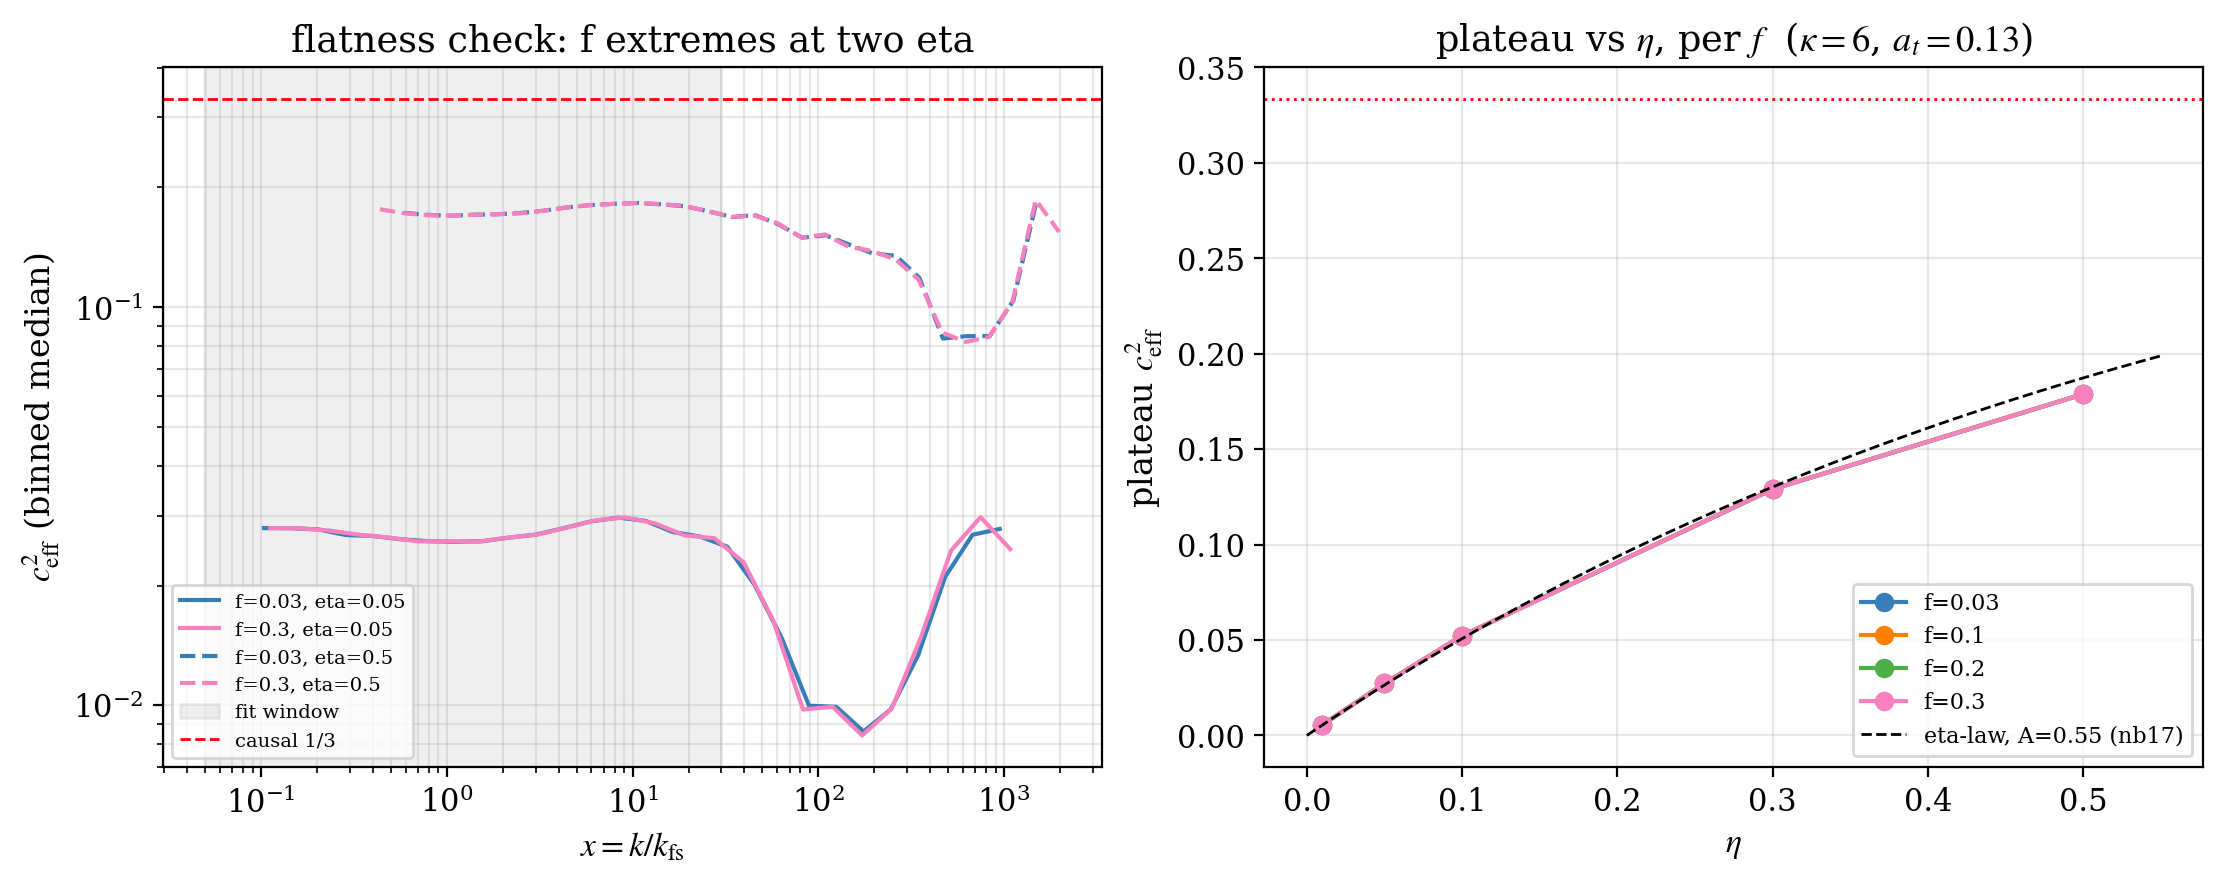

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)

# left: flatness check -- f extremes at two eta, fit window shaded
for eta, ls in zip([0.05, 0.5], ['-', '--']):
    for f, color in zip([F_SCAN[0], F_SCAN[-1]], [qual_colors[0], qual_colors[3]]):
        xb, cb = binned_median_curve(SERIES[(f, eta)])
        axes[0].loglog(xb, cb, ls, color=color, label='f={:g}, eta={:g}'.format(f, eta))
axes[0].axvspan(X_WINDOW[0], X_WINDOW[1], color='gray', alpha=0.12, label='fit window')
axes[0].axhline(1./3., color='red', ls='--', lw=1.0, label='causal 1/3')
axes[0].set_xlabel(r'$x = k/k_{\rm fs}$'); axes[0].set_ylabel(r'$c_{\rm eff}^2$ (binned median)')
axes[0].set_title('flatness check: f extremes at two eta')
axes[0].grid(True, which='both', alpha=0.3); axes[0].legend(fontsize=7)

# right: the raw material of the fit -- plateau vs eta, one curve per f
etas = np.asarray(ETA_SCAN)
for f, color in zip(F_SCAN, qual_colors):
    axes[1].plot(etas, [PLATEAU[(f, e)] for e in ETA_SCAN], 'o-', color=color,
                 label='f={:g}'.format(f))
eta_fine = np.linspace(0.0, 0.55, 200)
axes[1].plot(eta_fine, eta_plateau_cfs(eta_fine, A=0.55), 'k--', lw=1.0,
             label='eta-law, A=0.55 (nb17)')
axes[1].axhline(1./3., color='red', ls=':', lw=1.0)
axes[1].set_xlabel(r'$\eta$'); axes[1].set_ylabel(r'plateau $c_{\rm eff}^2$')
axes[1].set_title(r'plateau vs $\eta$, per $f$  ($\kappa=6$, $a_t=0.13$)')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.show()

## Stage B - fit ceff2(f, eta)

De-saturating with y = -ln(1-3c)/3 turns the saturating law into a straight line through the origin, y = A(f)*eta, so the fit is two ordinary least squares: per-f slopes A_f first, then the amplitude law A(f) = A0(1 + B f).

Two models are scored on the full grid:
- **null (eta-only):** one pooled amplitude A0, B = 0 -- the nb17 law refit on 4x more data;
- **f-corrected:** (A0, B) from the per-f slopes.

**Adoption rule (fixed before looking):** keep the f-correction only if it cuts the max grid residual by >= 30%; otherwise B := 0 and f-independence is the demonstrated result. The deliverable `ceff2_formula(f, eta)` binds the adopted constants and is what Stage C validates.

In [5]:
# per-f amplitude: desaturated plateau y = A_f * eta
A_PER_F = {f: fit_eta_slope(ETA_SCAN, [PLATEAU[(f, e)] for e in ETA_SCAN]) for f in F_SCAN}

# null model: one amplitude pooled over the whole grid
eta_pool = np.array([eta for f in F_SCAN for eta in ETA_SCAN])
c_pool   = np.array([PLATEAU[(f, eta)] for f in F_SCAN for eta in ETA_SCAN])
A0_NULL  = fit_eta_slope(eta_pool, c_pool)

# f-corrected model: A(f) = A0*(1 + B*f)
A0_FIT, B_FIT = fit_A_of_f(F_SCAN, [A_PER_F[f] for f in F_SCAN])

print('per-f amplitudes A_f:', {f: round(A_PER_F[f], 4) for f in F_SCAN})
print('null model:        A0 = {:.4f}  (B = 0)'.format(A0_NULL))
print('f-corrected model: A0 = {:.4f}, B = {:+.4f}'.format(A0_FIT, B_FIT))

def grid_residuals(A0, B):
    r = {(f, eta): float(ceff2_f_eta(f, eta, A0=A0, B=B))/PLATEAU[(f, eta)] - 1.0
         for f in F_SCAN for eta in ETA_SCAN}
    arr = np.array(list(r.values()))
    return r, float(np.max(np.abs(arr))), float(np.sqrt(np.mean(arr**2)))

r_null, max_null, rms_null = grid_residuals(A0_NULL, 0.0)
r_fcor, max_fcor, rms_fcor = grid_residuals(A0_FIT, B_FIT)
print('\nformula/plateau - 1 over the {}x{} grid:'.format(len(F_SCAN), len(ETA_SCAN)))
print('  null (eta only): max {:>6.1%}  rms {:>6.1%}'.format(max_null, rms_null))
print('  f-corrected:     max {:>6.1%}  rms {:>6.1%}'.format(max_fcor, rms_fcor))

print('\nper-point residuals, f-corrected model (rows eta, cols f):')
print('{:>6} |'.format('eta') + ''.join(' {:>8}'.format('f={:g}'.format(f)) for f in F_SCAN))
for eta in ETA_SCAN:
    print('{:>6g} |'.format(eta) + ''.join(' {:>+8.1%}'.format(r_fcor[(f, eta)]) for f in F_SCAN))

# adoption rule (fixed in the markdown above): f-correction must cut max residual >= 30%
if max_fcor < 0.7*max_null:
    A0_FINAL, B_FINAL = A0_FIT, B_FIT
    print('\nADOPTED: f-corrected model (max residual {:.1%} -> {:.1%})'.format(max_null, max_fcor))
else:
    A0_FINAL, B_FINAL = A0_NULL, 0.0
    print('\nADOPTED: eta-only model -- B is consistent with 0 at grid scatter'
          ' (f-correction bought only {:.1%} -> {:.1%})'.format(max_null, max_fcor))

def ceff2_formula(f, eta):
    """>>> DELIVERABLE <<<  ceff2(f, eta) = (1/3)(1 - exp(-3*A0*(1+B*f)*eta)),
    fitted constants below. Valid at kappa=6, a_t=0.13, m=1e16 GeV ONLY."""
    return ceff2_f_eta(f, eta, A0=A0_FINAL, B=B_FINAL)

print('\n===== FITTED FORMULA (kappa={:g}, a_t={:g} ONLY) ====='.format(KAPPA, A_T))
print('ceff2(f, eta) = (1/3) * (1 - exp(-3 * {:.4f} * (1 {} {:.4f}*f) * eta))'.format(
    A0_FINAL, '+' if B_FINAL >= 0 else '-', abs(B_FINAL)))
print('(passed to CLASS per run as ncdm_ceff2_eta_A = {:.4f}*(1 {} {:.4f}*f))'.format(
    A0_FINAL, '+' if B_FINAL >= 0 else '-', abs(B_FINAL)))

per-f amplitudes A_f: {0.03: 0.5222, 0.1: 0.5225, 0.2: 0.5222, 0.3: 0.5223}
null model:        A0 = 0.5223  (B = 0)
f-corrected model: A0 = 0.5223, B = -0.0004

formula/plateau - 1 over the 4x5 grid:
  null (eta only): max   7.8%  rms   5.6%
  f-corrected:     max   7.8%  rms   5.6%

per-point residuals, f-corrected model (rows eta, cols f):
   eta |   f=0.03    f=0.1    f=0.2    f=0.3
  0.01 |    -5.8%    -5.8%    -5.8%    -5.8%
  0.05 |    -7.8%    -7.8%    -7.7%    -7.7%
   0.1 |    -7.4%    -7.5%    -7.4%    -7.4%
   0.3 |    -3.0%    -3.1%    -3.1%    -3.1%
   0.5 |    +1.3%    +1.3%    +1.3%    +1.3%

ADOPTED: eta-only model -- B is consistent with 0 at grid scatter (f-correction bought only 7.8% -> 7.8%)

===== FITTED FORMULA (kappa=6, a_t=0.13 ONLY) =====
ceff2(f, eta) = (1/3) * (1 - exp(-3 * 0.5223 * (1 + 0.0000*f) * eta))
(passed to CLASS per run as ncdm_ceff2_eta_A = 0.5223*(1 + 0.0000*f))


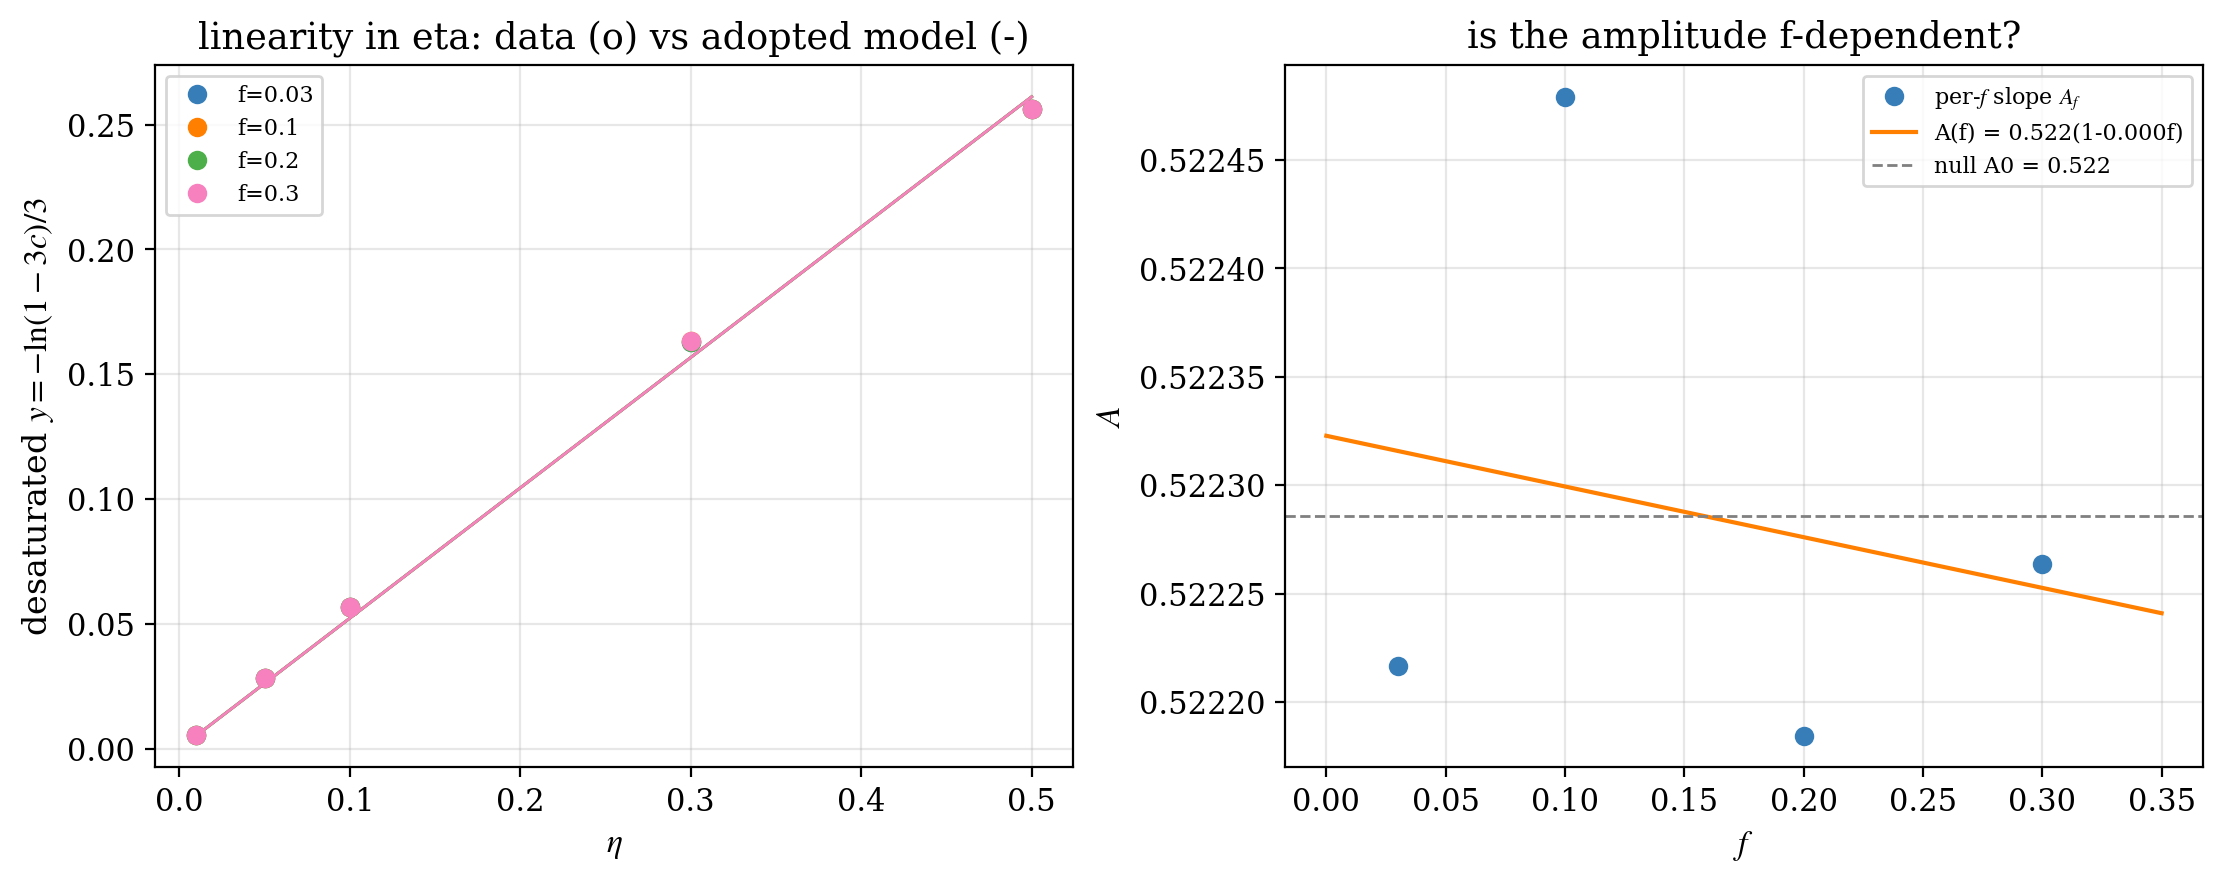

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)

# left: linearity in eta -- desaturated data vs adopted model, per f
etas = np.asarray(ETA_SCAN)
for f, color in zip(F_SCAN, qual_colors):
    y = desaturate_cfs([PLATEAU[(f, e)] for e in ETA_SCAN])
    axes[0].plot(etas, y, 'o', color=color, label='f={:g}'.format(f))
    axes[0].plot(etas, A_eff_of_f(f, A0_FINAL, B_FINAL)*etas, '-', color=color, lw=1.0)
axes[0].set_xlabel(r'$\eta$'); axes[0].set_ylabel(r'desaturated $y = -\ln(1-3c)/3$')
axes[0].set_title('linearity in eta: data (o) vs adopted model (-)')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

# right: the f-dependence question in one panel
fs = np.asarray(F_SCAN)
axes[1].plot(fs, [A_PER_F[f] for f in F_SCAN], 'o', color=qual_colors[0],
             label=r'per-$f$ slope $A_f$')
f_fine = np.linspace(0.0, 0.35, 100)
axes[1].plot(f_fine, A_eff_of_f(f_fine, A0_FIT, B_FIT), '-', color=qual_colors[1],
             label='A(f) = {:.3f}(1{}{:.3f}f)'.format(A0_FIT, '+' if B_FIT >= 0 else '-', abs(B_FIT)))
axes[1].axhline(A0_NULL, color='gray', ls='--', lw=1.0, label='null A0 = {:.3f}'.format(A0_NULL))
axes[1].set_xlabel(r'$f$'); axes[1].set_ylabel(r'$A$')
axes[1].set_title('is the amplitude f-dependent?')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.show()

## Stage C - P(k) validation of the fitted formula

Mode-3 fluid with `ncdm_ceff2_eta_A = A(f)` vs converged exact reference at the 4 grid corners + center; trigger 0.4 (safe switch-on, nb17); scored on **k <= 1 only**; target ~1%. Exact-reference q-schedule: 1001 for f <= 0.1, 5001 for f > 0.1 (memory `accdm-fluid-f-boundary`) -- the f = 0.3 references are the slow runs of this notebook.

The **fail-fast guard runs first** (cheap single fluid run): the stored `cs2_ncdm[1]` at late times (where ca2 << plateau) must equal `ceff2_formula(f, eta)` to < 1%. Both sides are closed-form functions of the same inputs, so any miss means the C run is not executing mode 3 with the A we passed -- the nb16 typo failure mode, made impossible to miss.

In [7]:
def run_pk_timed(params, k_list, tag):
    """P(k) at z=0 with wall-time; pickle-cached by tag. Prints cache-hit vs
    computing so a fast return is never mistaken for a skipped run."""
    cache_path = os.path.join(CACHE_DIR, tag + '.pkl')
    if os.path.exists(cache_path):
        print('[cache hit] {}'.format(tag), flush=True)
        with open(cache_path, 'rb') as cache_file:
            return pickle.load(cache_file)
    print('[computing] {} ...'.format(tag), flush=True)
    M = Class(); M.set(params)
    start = time.perf_counter(); M.compute(); elapsed = time.perf_counter() - start
    pk = np.array([M.pk(float(k), 0.0) for k in k_list])
    M.struct_cleanup(); M.empty()
    print('[done]      {} in {:.0f} s'.format(tag, elapsed), flush=True)
    result = (pk, elapsed)
    with open(cache_path, 'wb') as cache_file:
        pickle.dump(result, cache_file)
    return result

# # fail-fast guard (nb16 lesson): the C run must realize ceff2_formula(f, eta)
# f_chk, eta_chk = 0.1, 0.1
# p = fluid_params(f_chk, eta_chk, A_eff_of_f(f_chk, A0_FINAL, B_FINAL))
# p['k_output_values'] = '0.1'
# M = Class(); M.set(p); M.compute()
# d = M.get_perturbations()['scalar'][0]
# cfs_C = float(np.asarray(d['cs2_ncdm[1]'], float)[-1])   # late time: ca2 << plateau
# M.struct_cleanup(); M.empty()
# cfs_py = float(ceff2_formula(f_chk, eta_chk))
# print('C plateau {:.5f} vs formula {:.5f} ({:+.2%})'.format(cfs_C, cfs_py, cfs_C/cfs_py - 1))
# assert abs(cfs_C/cfs_py - 1) < 0.01, 'C is NOT running the mode-3 plateau with the passed A(f)'

In [8]:
REF, PKF, RES = {}, {}, {}
for f, eta in CORNERS:                                   # exact references (slow at f=0.3)
    q = q_exact_of_f(f)
    REF[(f, eta)] = run_pk_timed(accdm_params(f, eta, q), K_PK,
                                 'ref_f{:g}_eta{:g}_q{}'.format(f, eta, q))
for f, eta in CORNERS:                                   # mode-3 fluid with A(f)
    A_eff = float(A_eff_of_f(f, A0_FINAL, B_FINAL))
    tag = 'fluid3_f{:g}_eta{:g}_trig{:g}_A{:.4f}'.format(f, eta, TRIGGER, A_eff)
    try:
        pk, dt = run_pk_timed(fluid_params(f, eta, A_eff), K_PK, tag)
        PKF[(f, eta)] = pk
        r = pk/REF[(f, eta)][0] - 1.0
        RES[(f, eta)] = (float(np.nanmax(np.abs(r))), float(np.sqrt(np.nanmean(r**2))), dt)
    except Exception as e:
        RES[(f, eta)] = None
        print('CRASH f={} eta={}: {}'.format(f, eta, str(e)[:120]))

print('\n{:>5} {:>5} {:>8} | {:>9} {:>9} {:>9} {:>8}'.format(
    'f', 'eta', 'A(f)', 'max', 'rms', 'exact[s]', 'speedup'))
for f, eta in CORNERS:
    A_eff = float(A_eff_of_f(f, A0_FINAL, B_FINAL))
    ref_t = REF[(f, eta)][1]
    v = RES[(f, eta)]
    if v:
        print('{:>5g} {:>5g} {:>8.4f} | {:>9.2e} {:>9.2e} {:>9.0f} {:>7.1f}x'.format(
            f, eta, A_eff, v[0], v[1], ref_t, ref_t/max(v[2], 1e-9)))
    else:
        print('{:>5g} {:>5g} {:>8.4f} | {:>9} {:>9} {:>9.0f}'.format(
            f, eta, A_eff, 'CRASH', '-', ref_t))

[cache hit] ref_f0.1_eta0.05_q1001
[cache hit] ref_f0.1_eta0.5_q1001
[cache hit] ref_f0.3_eta0.05_q5001
[cache hit] ref_f0.3_eta0.5_q5001
[cache hit] ref_f0.2_eta0.1_q5001
[cache hit] fluid3_f0.1_eta0.05_trig10_A0.5223
[cache hit] fluid3_f0.1_eta0.5_trig10_A0.5223
[cache hit] fluid3_f0.3_eta0.05_trig10_A0.5223
[computing] fluid3_f0.3_eta0.5_trig10_A0.5223 ...
[done]      fluid3_f0.3_eta0.5_trig10_A0.5223 in 836 s
[computing] fluid3_f0.2_eta0.1_trig10_A0.5223 ...
[done]      fluid3_f0.2_eta0.1_trig10_A0.5223 in 821 s

    f   eta     A(f) |       max       rms  exact[s]  speedup
  0.1  0.05   0.5223 |  5.92e-02  1.81e-02        34     1.3x
  0.1   0.5   0.5223 |  2.33e-02  5.70e-03        35     1.3x
  0.3  0.05   0.5223 |  1.58e-01  4.76e-02      1211     1.4x
  0.3   0.5   0.5223 |  5.97e-02  1.58e-02      1247     1.5x
  0.2   0.1   0.5223 |  7.21e-02  2.32e-02      1205     1.5x


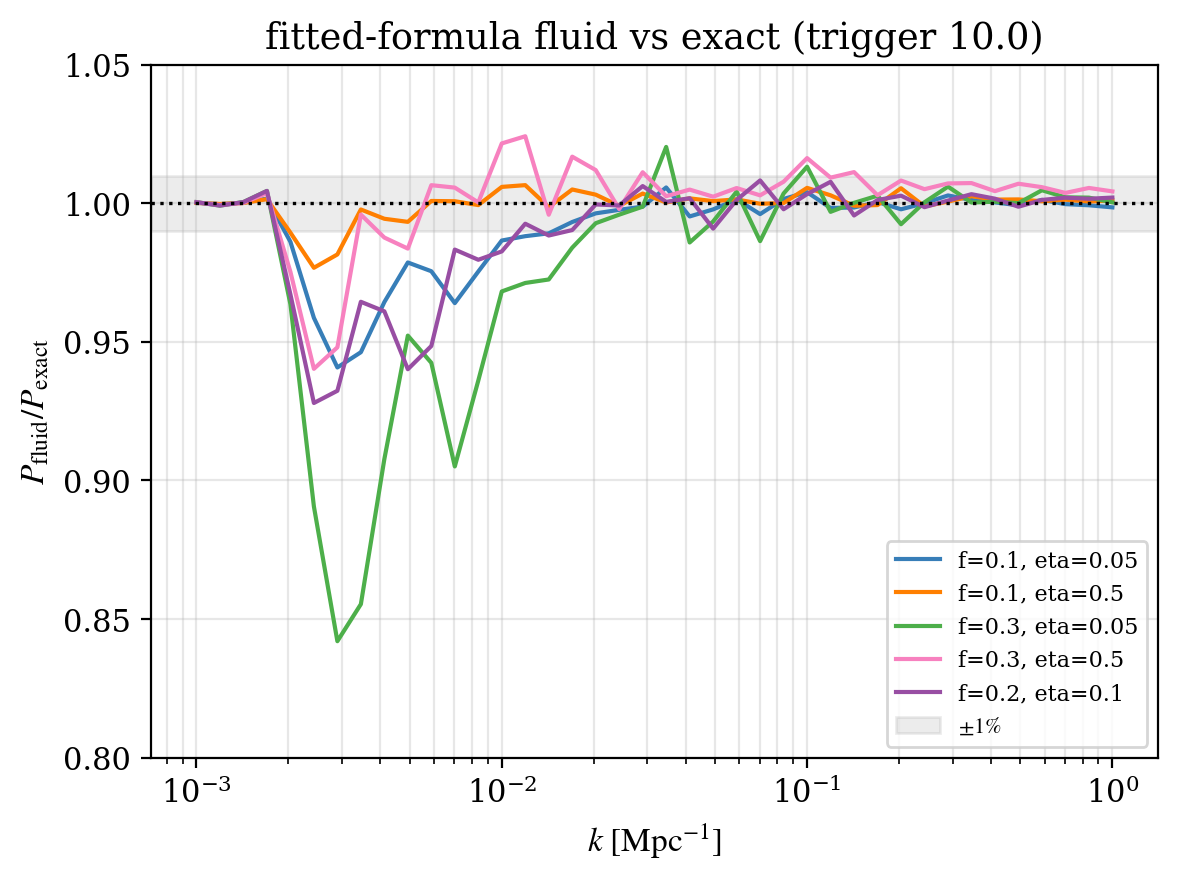

In [11]:
plt.figure(figsize=(6.5, 4.5))
for (f, eta), color in zip(CORNERS, qual_colors):
    if (f, eta) in PKF:
        plt.semilogx(K_PK, PKF[(f, eta)]/REF[(f, eta)][0], '-', color=color,
                     label='f={:g}, eta={:g}'.format(f, eta))
plt.axhline(1.0, color='black', ls=':', lw=1.2)
plt.axhspan(0.99, 1.01, color='gray', alpha=0.15, label=r'$\pm 1\%$')
plt.xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$'); plt.ylabel(r'$P_{\rm fluid}/P_{\rm exact}$')
plt.title('fitted-formula fluid vs exact (trigger {})'.format(TRIGGER))
plt.ylim(0.8, 1.05); plt.grid(True, which='both', alpha=0.3); plt.legend(fontsize=8)
plt.show()

## Verdict (fill from output)

- **Stage A:** plateau f-spread per eta = [FILL] -> f-dependence [real / absent] at grid scatter.
- **Stage B:** A0 = [FILL], B = [FILL]; adopted model = [eta-only / f-corrected]; grid residual max/rms = [FILL]. Final formula: `ceff2(f, eta) = (1/3)(1 - exp(-3*[A0]*(1 + [B]*f)*eta))`.
- **Stage C:** max P(k) residual over k <= 1 per corner = [FILL]; meets ~1%? [YES/NO]; the f = 0.3 corners specifically: [FILL].
- Speedup exact -> fluid per corner = [FILL]x -- compare against the plain q-size reduction (memory `daughter-qsize-overkill`) before adopting the fluid anywhere.
- C-vs-python plateau guard: [FILL]% (must be < 1%; a miss means the mode is not wired in).
- Failure signatures: residuals growing with **eta** -> refit A (amplitude law fine); growing with **k** at fixed (f, eta) -> shear closure `cvis2` or the k-independence assumption (do NOT tune ceff2); growing with **f** -> the linear A(f) form is wrong (try refit before inventing new forms).

**Keep in sync:** `ceff2_f_eta` / `A_eff_of_f` (python, unit-tested) with the mode-3 branch of `pba->cfs_acc` in background.c -- the C side receives A(f) per run via `ncdm_ceff2_eta_A`, it does not know about f. Universality of (A0, B) in (kappa, a_t) is untested and out of scope (spec `2026-07-13-ceff2-f-eta-formula-design.md`).